# MountainCar Discretization

This notebook builds a finite abstract MDP for `MountainCar-v0`.


In [ ]:
%load_ext autoreload
%autoreload 2

import math
import numpy as np
import random
import torch
import pandas as pd
import sys
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import gymnasium as gym
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import itertools
import imageio

# This starts from the current working directory
# and goes up until it finds the 'fogas_torch' folder or '.git'
def find_root(current_path, marker="fogas_torch"):
    current_path = Path(current_path).resolve()
    for parent in [current_path] + list(current_path.parents):
        if (parent / marker).exists():
            return parent
    return current_path

PROJECT_ROOT = find_root(Path.cwd())
print(f"Project root found at: {PROJECT_ROOT}")
DATASET_PATH = PROJECT_ROOT / "datasets" / "mountaincar.csv"

# Add project root to sys.path so we can import local packages
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from fogas_torch import LinearMDP, PolicySolver, EnvDataCollector
from fogas_torch.algorithm import (
    FOGASSolverVectorized,
    FOGASOracleSolverVectorized,
    FOGASHyperOptimizer,
    FOGASEvaluator,
    FOGASDataset,
)
from fogas_torch import (
    BoxStateDiscretizer,
    DiscreteActionDiscretizer,
    DiscretizedLinearMDP,
)
from fogas_torch.dataset_collection.dataset_analyzer import DatasetAnalyzer
from fogas_torch.fqi.fqi_solver import FQISolver
from fogas_torch.fqi.fqi_evaluator import FQIEvaluator

seed = 44
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Project root found at: /shared/home/mauro.diaz/work/FOGAS
Using device: cuda


## Discretization design

MountainCar observations are `(position, velocity)`.

State grid:
- `position`: 36 bins on `[-1.2, 0.6]`
- `velocity`: 28 bins on `[-0.07, 0.07]`

This gives `36 * 28 = 1008` non-terminal abstract states.

Action space:
- `0`: push left
- `1`: no push
- `2`: push right

The environment already has an exact **discrete** action space, so unlike the continuous version there is no action discretization step.

We add one absorbing abstract state:
- `GOAL_STATE_ID`: successful termination (`position >= 0.5` and `velocity >= goal_velocity`)

Total abstract states: `1009`.

As with the continuous notebook, we do not infer `P` and `r` from data. Gymnasium already gives the exact transition and reward equations, so we build the abstract model directly from them.

We also do **not** add a separate time-limit state. The `200`-step truncation is a wrapper-level constraint that depends on elapsed time, not only on the observation, so it is recorded in the offline dataset but excluded from the Markov abstraction itself.


In [49]:
ENV_ID = "MountainCar-v0"
GAMMA = 0.9
GOAL_POSITION = 0.5
GOAL_VELOCITY = 0.0
MIN_POSITION = -1.2
MAX_POSITION = 0.6
MAX_SPEED = 0.07
FORCE = 0.001
GRAVITY_COEFF = 0.0025
TIME_LIMIT = 200

STATE_BINS = np.array([20, 20], dtype=np.int64)
OBS_LOW = np.array([MIN_POSITION, -MAX_SPEED], dtype=np.float64)
OBS_HIGH = np.array([MAX_POSITION, MAX_SPEED], dtype=np.float64)

ACTION_IDS = np.array([0, 1, 2], dtype=np.int64)
ACTION_LABELS = {0: "left", 1: "coast", 2: "right"}

INITIAL_OBS_REFERENCE = np.array([-0.5, 0.0], dtype=np.float64)

state_disc = BoxStateDiscretizer(
    low=OBS_LOW,
    high=OBS_HIGH,
    bins=STATE_BINS,
    terminal_obs_predicate=lambda obs: obs[0] >= GOAL_POSITION and obs[1] >= GOAL_VELOCITY,
)

action_disc = DiscreteActionDiscretizer(
    action_values=ACTION_IDS,
    action_labels=ACTION_LABELS,
)

CORE_STATE_COUNT = state_disc.core_state_count
GOAL_STATE_ID = state_disc.absorbing_state_id
N_STATES = state_disc.n_states
N_ACTIONS = action_disc.n_actions

states = torch.arange(N_STATES, dtype=torch.int64)
actions = torch.arange(N_ACTIONS, dtype=torch.int64)

BIN_EDGES = state_disc.bin_edges
BIN_CENTERS = state_disc.bin_centers

def obs_to_state_id_nonterminal(obs):
    return state_disc.multi_bin_to_state_id(state_disc.obs_to_multi_bin(obs))

clip_obs = state_disc.clip
is_goal_obs = state_disc.is_terminal_obs
obs_to_multi_bin = state_disc.obs_to_multi_bin
multi_bin_to_state_id = state_disc.multi_bin_to_state_id
state_id_to_multi_bin = state_disc.state_id_to_multi_bin
obs_to_state_id = obs_to_state_id_nonterminal
state_id_to_center_obs = state_disc.state_id_to_center_obs

action_id_to_label = action_disc.action_id_to_label

INITIAL_STATE_ID = obs_to_state_id(INITIAL_OBS_REFERENCE)

env = gym.make(ENV_ID, goal_velocity=GOAL_VELOCITY)
sampled_initial_obs, _ = env.reset(seed=seed)
env.close()

print(f"Sampled initial observation: {sampled_initial_obs}")
print(f"Reference initial observation: {INITIAL_OBS_REFERENCE}")
print(f"Reference initial abstract state id: {INITIAL_STATE_ID}")
print(f"Non-terminal abstract states: {CORE_STATE_COUNT}")
print(f"Total abstract states: {N_STATES}")
print(f"Discrete action ids: {ACTION_IDS}")
print(f"Action labels: {[action_id_to_label(int(a)) for a in ACTION_IDS]}")

Sampled initial observation: [-0.5754869  0.       ]
Reference initial observation: [-0.5  0. ]
Reference initial abstract state id: 150
Non-terminal abstract states: 400
Total abstract states: 401
Discrete action ids: [0 1 2]
Action labels: ['left', 'coast', 'right']


## Evaluation methods

In [50]:
def plot_policy(
    pi,
    state_disc,
    action_disc,
    title="Greedy Policy in MountainCar Phase Space",
    colors=("#440154", "#21918c", "#fde725"),
    figsize=(12, 7),
    draw_boundaries=True,
    ax=None,
):
    N_STATES = state_disc.n_states
    N_ACTIONS = action_disc.n_actions
    STATE_BINS = state_disc.bins
    BIN_CENTERS = state_disc.bin_centers
    BIN_EDGES = state_disc.bin_edges
    CORE_STATE_COUNT = state_disc.core_state_count
    state_id_to_multi_bin = state_disc.state_id_to_multi_bin
    action_labels = [action_disc.action_id_to_label(a) for a in range(N_ACTIONS)]
    
    if CORE_STATE_COUNT is None:
        CORE_STATE_COUNT = int(np.prod(STATE_BINS))  # ← was N_STATES


    # --- Greedy actions ---
    pi_mat = pi.reshape(N_STATES, N_ACTIONS)
    greedy_actions = torch.argmax(pi_mat, dim=1).cpu().numpy()

    # --- Fill policy grid ---
    policy_grid = np.full(tuple(STATE_BINS), fill_value=-1, dtype=np.int64)
    for s in range(CORE_STATE_COUNT):
        i, j = state_id_to_multi_bin(s)
        policy_grid[i, j] = greedy_actions[s]

    # --- Colormap ---
    n_actions = len(action_labels)
    cmap = ListedColormap(list(colors)[:n_actions])
    norm = BoundaryNorm(
        [-0.5 + k for k in range(n_actions + 1)], cmap.N
    )

    # --- Figure / Axes ---
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = None

    X, V = np.meshgrid(BIN_CENTERS[0], BIN_CENTERS[1], indexing="ij")

    pcm = ax.pcolormesh(
        BIN_EDGES[0],
        BIN_EDGES[1],
        policy_grid.T,
        cmap=cmap,
        norm=norm,
        shading="flat",
    )

    if draw_boundaries:
        for a in range(n_actions - 1):
            ax.contour(
                X, V,
                (policy_grid == a).astype(float),
                levels=[0.5],
                linewidths=1.2,
            )

    ax.set_xlabel("Position")
    ax.set_ylabel("Velocity")
    ax.set_title(title)

    target_fig = fig if own_fig else ax.get_figure()
    cbar = target_fig.colorbar(pcm, ax=ax, ticks=list(range(n_actions)))
    cbar.ax.set_yticklabels(list(action_labels))

    if own_fig:
        plt.tight_layout()
        plt.show()

    return fig, ax


In [51]:
def evaluate_and_save_gif(
    policy,
    state_disc,
    action_disc,
    filename,
    env_id=ENV_ID,
    fps=30,
):
    """
    Evaluate a policy in the environment and save a GIF.

    Args:
        policy: Tensor/array of shape (N_STATES, N_ACTIONS) or (N_STATES,).
        state_disc: BoxStateDiscretizer.
        action_disc: DiscreteActionDiscretizer.
        filename: Output GIF path.
        env_id: Gymnasium environment ID.
        fps: Frames per second.
    """
    print(f"Starting simulation for {filename}...")

    is_distribution = (len(policy.shape) == 2)

    test_env = gym.make(env_id, render_mode="rgb_array")
    obs, info = test_env.reset()

    total_reward = 0.0
    steps = 0
    done = False
    frames = [test_env.render()]

    while not done:
        state_id = state_disc.obs_to_state_id(obs)

        if is_distribution:
            if hasattr(policy, "detach"):
                action_id = int(torch.argmax(policy[state_id]))
            else:
                action_id = int(np.argmax(policy[state_id]))
        else:
            action_id = int(policy[state_id])

        env_action = action_disc.action_id_to_env_action(action_id)

        obs, reward, terminated, truncated, info = test_env.step(env_action)
        frames.append(test_env.render())

        total_reward += reward
        steps += 1
        done = terminated or truncated

    test_env.close()

    status = "Success! Reached goal" if terminated else "Failed (Time Limit)"
    print(f"{status} in {steps} steps. Total Reward: {total_reward}")

    print(f"Saving GIF to {filename}...")
    imageio.mimsave(filename, frames, fps=fps)
    print("Done!")

In [52]:
def evaluate_policy_mean_steps(
    policy,
    state_disc,
    action_disc,
    env_id=ENV_ID,
    n_trials=5,
    max_steps=200,
):
    """
    Simulate a policy multiple times and return mean steps.

    Args:
        policy: Tensor/array of shape (N_STATES, N_ACTIONS) or (N_STATES,).
        state_disc: BoxStateDiscretizer.
        action_disc: DiscreteActionDiscretizer.
        env_id: Gymnasium environment ID.
        n_trials: Number of trials.
        max_steps: Max steps per episode.

    Returns:
        float: Mean number of steps.
    """
    is_distribution = (len(policy.shape) == 2)
    test_env = gym.make(env_id, max_episode_steps=max_steps)

    total_steps_list = []

    for trial in range(n_trials):
        obs, _ = test_env.reset()
        done = False
        steps = 0

        while not done:
            state_id = state_disc.obs_to_state_id(obs)

            if is_distribution:
                if hasattr(policy, "detach"):
                    action_id = int(torch.argmax(policy[state_id]))
                else:
                    action_id = int(np.argmax(policy[state_id]))
            else:
                action_id = int(policy[state_id])

            env_action = action_disc.action_id_to_env_action(action_id)

            obs, reward, terminated, truncated, _ = test_env.step(env_action)
            steps += 1
            done = terminated or truncated

        total_steps_list.append(steps)

    test_env.close()

    mean_steps = sum(total_steps_list) / n_trials
    success_count = sum(1 for s in total_steps_list if s < max_steps)

    print(
        f"Evaluation over {n_trials} trials: "
        f"Mean Steps = {mean_steps:.2f} ({success_count}/{n_trials} reached goal)"
    )

    return mean_steps

In [53]:
def print_policy_rows(
    policy,
    state_disc,
    action_disc,
    compare_policy=None,
    include_goal=False,
    decimals=3,
):
    N_STATES = state_disc.n_states
    N_ACTIONS = action_disc.n_actions
    CORE_STATE_COUNT = state_disc.core_state_count
    GOAL_STATE_ID = state_disc.absorbing_state_id

    policy = torch.as_tensor(policy, dtype=torch.float64).reshape(N_STATES, N_ACTIONS).cpu()

    compare = None
    if compare_policy is not None:
        compare = torch.as_tensor(compare_policy, dtype=torch.float64).reshape(N_STATES, N_ACTIONS).cpu()

    max_state = N_STATES if include_goal else CORE_STATE_COUNT

    print()
    print("Policy rows")
    print("Legend:", [action_disc.action_id_to_label(a) for a in range(N_ACTIONS)])
    if compare is not None:
        print("Format: main policy | compare policy")
    print()

    for s in range(max_state):
        obs = state_disc.state_id_to_center_obs(s)

        if obs is None:
            pos_str = "nan"
            vel_str = "nan"
        else:
            pos_str = f"{obs[0]: .3f}"
            vel_str = f"{obs[1]: .3f}"

        probs = policy[s].numpy()
        probs_str = "[" + ", ".join(f"{p:.{decimals}f}" for p in probs) + "]"
        greedy_main = action_disc.action_id_to_label(int(torch.argmax(policy[s]).item()))

        line = (
            f"s={s:3d}  "
            f"pos={pos_str:>7}  vel={vel_str:>7}  "
            f"pi={probs_str}  "
            f"argmax={greedy_main}"
        )

        if compare is not None:
            probs_cmp = compare[s].numpy()
            probs_cmp_str = "[" + ", ".join(f"{p:.{decimals}f}" for p in probs_cmp) + "]"
            greedy_cmp = action_disc.action_id_to_label(int(torch.argmax(compare[s]).item()))
            same = torch.argmax(policy[s]).item() == torch.argmax(compare[s]).item()
            mark = "same" if same else "DIFF"
            line += f"   |   cmp={probs_cmp_str}  argmax={greedy_cmp}  -> {mark}"

        print(line)

## MDP construction

In [54]:
RBF_BINS = np.array([10, 10], dtype=np.int64)

RBF_EDGES = [
    np.linspace(lo, hi, n_bins + 1, dtype=np.float64)
    for lo, hi, n_bins in zip(OBS_LOW, OBS_HIGH, RBF_BINS)
]
RBF_GRID_CENTERS = [0.5 * (edges[:-1] + edges[1:]) for edges in RBF_EDGES]
RBF_CENTERS = np.array(list(itertools.product(*RBF_GRID_CENTERS)), dtype=np.float64)

K_CENTERS = len(RBF_CENTERS)

width_position = (MAX_POSITION - MIN_POSITION) / RBF_BINS[0]
width_velocity = (MAX_SPEED - (-MAX_SPEED)) / RBF_BINS[1]
VARIANCE_SCALE = 0.5
SIGMA_SQUARED = np.array(
    [width_position**2, width_velocity**2],
    dtype=np.float64,
) * VARIANCE_SCALE

D_RBF = K_CENTERS * action_disc.n_actions

def phi_rbf(state_id, action_id):
    obs = state_disc.state_id_to_center_obs(state_id)

    if obs is None:
        return torch.zeros(D_RBF, dtype=torch.float64)

    diff_sq = (RBF_CENTERS - obs) ** 2
    f_x = np.exp(-0.5 * np.sum(diff_sq / SIGMA_SQUARED, axis=1))

    feat = np.zeros(D_RBF, dtype=np.float64)
    start_idx = int(action_id) * K_CENTERS
    end_idx = start_idx + K_CENTERS
    feat[start_idx:end_idx] = f_x

    return torch.from_numpy(feat)

print(f"Number of RBF centers (k): {K_CENTERS}")
print(f"Total feature dimension (d): {D_RBF}")


Number of RBF centers (k): 100
Total feature dimension (d): 300


In [55]:
def mountaincar_step(obs, action_id, goal_velocity=GOAL_VELOCITY):
    position, velocity = np.asarray(obs, dtype=np.float64)
    action_id = int(action_id)

    if action_id not in (0, 1, 2):
        raise ValueError(f"MountainCar action must be 0, 1, or 2. Got {action_id}.")

    velocity = velocity + (action_id - 1) * FORCE - GRAVITY_COEFF * math.cos(3.0 * position)
    velocity = float(np.clip(velocity, -MAX_SPEED, MAX_SPEED))

    position = position + velocity
    position = float(np.clip(position, MIN_POSITION, MAX_POSITION))

    if position == MIN_POSITION and velocity < 0.0:
        velocity = 0.0

    terminated = bool(position >= GOAL_POSITION and velocity >= goal_velocity)
    reward = -1.0

    next_obs = np.array([position, velocity], dtype=np.float64)
    return next_obs, float(reward), terminated


abstract_states = torch.arange(state_disc.n_states, dtype=torch.int64)
abstract_actions = torch.arange(action_disc.n_actions, dtype=torch.int64)

helper_mdp = DiscretizedLinearMDP(
    state_discretizer=state_disc,
    action_discretizer=action_disc,
    transition_fn=mountaincar_step,
    gamma=GAMMA ** 5,
    initial_obs=INITIAL_OBS_REFERENCE,
)

P = helper_mdp.P
reward_fn = helper_mdp.reward_fn
x0 = helper_mdp.x0
terminal_states = helper_mdp.terminal_states

mdp = LinearMDP(
    states=abstract_states,
    actions=abstract_actions,
    phi=phi_rbf,
    reward_fn=reward_fn,
    gamma=GAMMA ** 5,
    x0=x0,
    P=P,
    terminal_states=terminal_states,
)


## Q-Learning solving

In [56]:
def run_q_learning(
    episodes=5000,
    alpha=0.9,
    gamma=0.99,
    epsilon_start=1.0,
    render=False,
    seed=44,
):
    env = gym.make(
        ENV_ID,
        goal_velocity=GOAL_VELOCITY,
        render_mode="human" if render else None,
    )

    rng = np.random.default_rng(seed)
    q = np.zeros((N_STATES, N_ACTIONS), dtype=np.float64)

    rewards_per_episode = np.zeros(episodes, dtype=np.float64)

    epsilon = epsilon_start
    epsilon_decay_rate = 2 / episodes

    for ep in range(episodes):
        obs, _ = env.reset(seed=seed + ep)
        s = obs_to_state_id(obs)

        terminated = False
        ep_reward = 0.0

        while (not terminated) and (ep_reward > -1000):
            if rng.random() < epsilon:
                a = env.action_space.sample()
            else:
                a = int(np.argmax(q[s]))

            next_obs, reward, terminated, truncated, _ = env.step(a)

            if terminated:
                next_s = GOAL_STATE_ID
            else:
                next_s = obs_to_state_id(next_obs)

            q[s, a] = q[s, a] + alpha * (
                reward + gamma * np.max(q[next_s]) - q[s, a]
            )

            s = next_s
            ep_reward += reward

            if truncated:
                break

        epsilon = max(epsilon - epsilon_decay_rate, 0.0)
        rewards_per_episode[ep] = ep_reward

    env.close()

    q_torch = torch.from_numpy(q).to(dtype=torch.float64)
    greedy_actions = torch.argmax(q_torch, dim=1)

    mean_rewards = np.array([
        rewards_per_episode[max(0, t - 99): t + 1].mean()
        for t in range(episodes)
    ])

    plt.figure(figsize=(8, 4))
    plt.plot(mean_rewards)
    plt.xlabel("Episode")
    plt.ylabel("Mean reward (last 100)")
    plt.title("Q-learning on discretized MountainCar")
    plt.show()

    print("Initial state greedy action:", action_id_to_label(greedy_actions[INITIAL_STATE_ID].item()))
    print("Q(initial state):", q_torch[INITIAL_STATE_ID])

    return q_torch, greedy_actions, rewards_per_episode


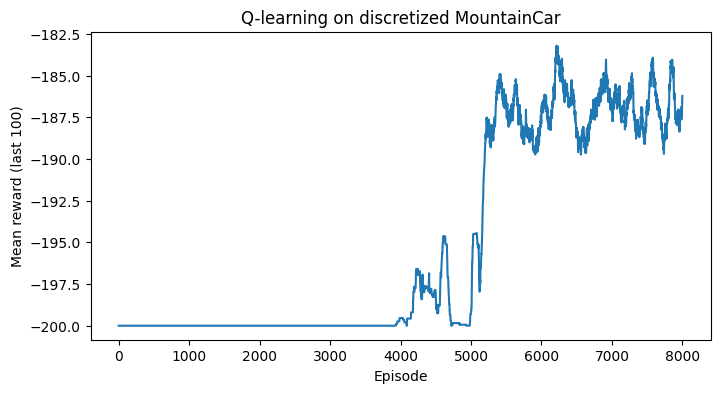

Initial state greedy action: right
Q(initial state): tensor([-10.0000, -10.0000,  -9.9990], dtype=torch.float64)


In [62]:
q_star_ql, greedy_actions_ql, rewards_ql = run_q_learning(
    episodes=8000,
    alpha=0.9,
    gamma=0.9,
    epsilon_start=1.0,
    render=False,
    seed=seed,
)

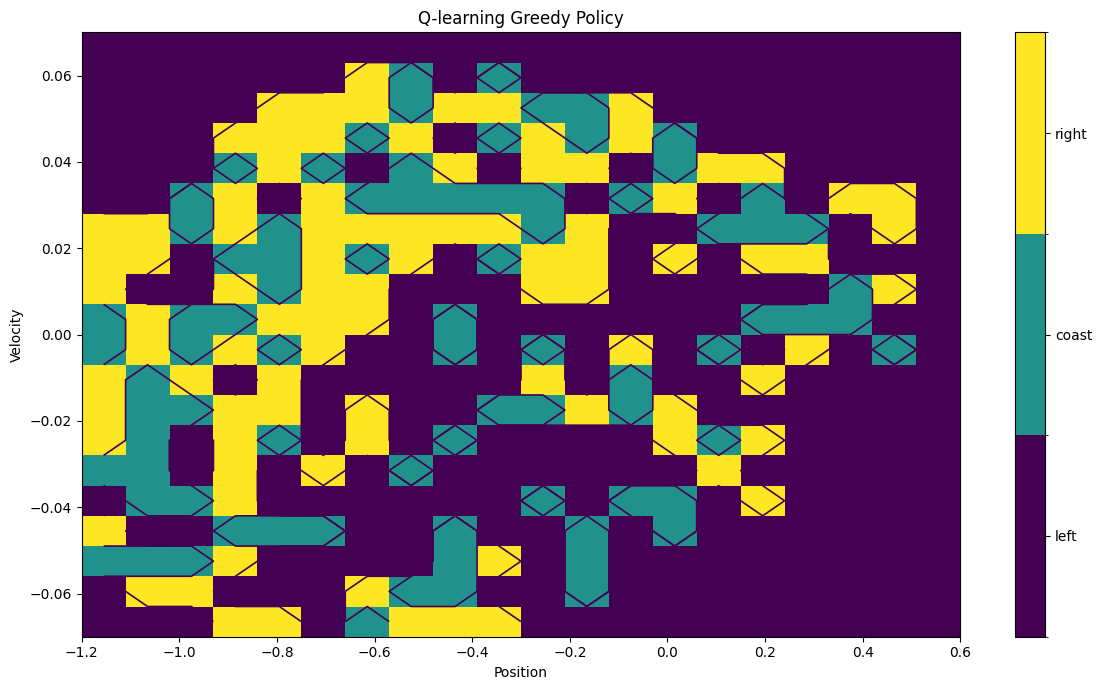

Starting simulation for mountain_car_optimal.gif...


ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1334:(snd_func_refer) error evaluating name
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5701:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2664:(snd_pcm_open_noupdate) Unknown PCM default


Failed (Time Limit) in 200 steps. Total Reward: -200.0
Saving GIF to mountain_car_optimal.gif...
Done!


In [58]:
# From learned Q-table -> greedy deterministic policy matrix
greedy_actions_ql = torch.argmax(q_star_ql, dim=1)

pi_matrix_ql = torch.zeros((N_STATES, N_ACTIONS), dtype=torch.float64)
pi_matrix_ql[torch.arange(N_STATES), greedy_actions_ql] = 1.0

# Optional: make goal state uniform instead of one-hot
pi_matrix_ql[GOAL_STATE_ID] = 1.0 / N_ACTIONS

plot_policy(
    pi_matrix_ql,
    state_disc,
    action_disc,
    title="Q-learning Greedy Policy",
)

evaluate_and_save_gif(
    pi_matrix_ql,
    state_disc,
    action_disc,
    "mountain_car_optimal.gif",
)

## Dataset Collection

Personalized dataset collection using the environment of gym, macro steps etc...

As we cant compute the occupancy as in grid, here we compute a trajectory of the optimal policy and that will be our occupancy.

In [23]:
def build_uniform_reset_distribution_from_policy_trajectory(
    policy_matrix,
    state_disc,
    action_disc,
    env_id=ENV_ID,
    start_obs=INITIAL_OBS_REFERENCE,
    max_steps=TIME_LIMIT,
    seed=42,
    goal_velocity=GOAL_VELOCITY,
):
    if hasattr(policy_matrix, "detach"):
        policy_matrix = policy_matrix.detach().cpu().numpy()
    else:
        policy_matrix = np.asarray(policy_matrix, dtype=np.float64)

    expected_shape = (state_disc.n_states, action_disc.n_actions)
    if policy_matrix.shape != expected_shape:
        raise ValueError(
            f"policy_matrix must have shape {expected_shape}, got {policy_matrix.shape}"
        )

    env = gym.make(env_id, goal_velocity=goal_velocity)
    env.reset(seed=seed)

    obs = np.asarray(start_obs, dtype=np.float64).copy()
    env.unwrapped.state = obs.copy()

    trajectory_state_ids = []
    steps = 0

    for _ in range(max_steps):
        if state_disc.is_terminal_obs(obs):
            break

        s = state_disc.obs_to_state_id(obs)
        trajectory_state_ids.append(s)

        action_id = int(np.argmax(policy_matrix[s]))
        env_action = action_disc.action_id_to_env_action(action_id)

        obs, _, terminated, truncated, _ = env.step(env_action)
        obs = np.asarray(obs, dtype=np.float64)

        steps += 1
        if terminated or truncated:
            break

    env.close()

    unique_state_ids = list(dict.fromkeys(trajectory_state_ids))
    if len(unique_state_ids) == 0:
        raise ValueError("The trajectory from the initial state did not visit any non-terminal states.")

    uniform_prob = 1.0 / len(unique_state_ids)
    reset_distribution = {int(s): uniform_prob for s in unique_state_ids}

    return unique_state_ids, reset_distribution, steps

Compute the dataset:

In [25]:
def collect_change_of_state_dataset_from_env_policy(
    policy_matrix,
    state_disc,
    action_disc,
    env_id=ENV_ID,
    n_transitions=50_000,
    gamma=0.9,
    epsilon=0.2,
    proportions=(0.7, 0.3),
    episode_based=True,
    max_steps_per_episode=500,
    reset_probs=None,
    custom_reset_distribution=None,
    reset_obs_mode="uniform_in_bin",
    seed=42,
    save_path=None,
    verbose=True,
    max_repeat_same_state=10_000,
    drop_self_transitions=False,
    add_goal_self_loops=True,
    goal_self_loops_per_hit=1,
    goal_self_loop_reward=0.0,
    goal_self_loop_action="sample",
    start_obs=INITIAL_OBS_REFERENCE,
    goal_velocity=GOAL_VELOCITY,
):
    rng = np.random.default_rng(seed)
    env = gym.make(env_id, goal_velocity=goal_velocity)

    N_STATES = state_disc.n_states
    N_ACTIONS = action_disc.n_actions
    CORE_STATE_COUNT = state_disc.core_state_count
    GOAL_STATE_ID = state_disc.absorbing_state_id
    BIN_EDGES = state_disc.bin_edges

    if reset_probs is None:
        reset_probs = {"x0": 0.5, "random": 0.5}

    if hasattr(policy_matrix, "detach"):
        policy_matrix = policy_matrix.detach().cpu().numpy()
    else:
        policy_matrix = np.asarray(policy_matrix, dtype=np.float64)

    if policy_matrix.shape != (N_STATES, N_ACTIONS):
        raise ValueError(
            f"policy_matrix must have shape {(N_STATES, N_ACTIONS)}, got {policy_matrix.shape}"
        )

    row_sums = policy_matrix.sum(axis=1, keepdims=True)
    bad_rows = np.isclose(row_sums, 0.0).squeeze()
    if np.any(bad_rows):
        policy_matrix = policy_matrix.copy()
        policy_matrix[bad_rows] = 1.0 / N_ACTIONS
        row_sums = policy_matrix.sum(axis=1, keepdims=True)
    policy_matrix = policy_matrix / row_sums

    p_policy, p_random = proportions
    if not np.isclose(p_policy + p_random, 1.0):
        raise ValueError("proportions must sum to 1.0")

    reset_mode_names = list(reset_probs.keys())
    reset_mode_probs = np.array(list(reset_probs.values()), dtype=np.float64)
    if np.any(reset_mode_probs < 0):
        raise ValueError("reset_probs must be nonnegative")
    if np.isclose(reset_mode_probs.sum(), 0.0):
        raise ValueError("reset_probs must have positive total mass")
    reset_mode_probs = reset_mode_probs / reset_mode_probs.sum()

    if "custom" in reset_mode_names:
        if custom_reset_distribution is None:
            raise ValueError(
                "custom_reset_distribution must be provided when reset_probs includes 'custom'."
            )
        if not isinstance(custom_reset_distribution, dict):
            raise TypeError(
                "custom_reset_distribution must be a dict mapping state_id -> probability."
            )

        custom_state_ids = np.array(list(custom_reset_distribution.keys()), dtype=np.int64)
        custom_state_probs = np.array(list(custom_reset_distribution.values()), dtype=np.float64)

        if len(custom_state_ids) == 0:
            raise ValueError("custom_reset_distribution cannot be empty.")
        if np.any(custom_state_ids < 0) or np.any(custom_state_ids >= CORE_STATE_COUNT):
            raise ValueError(
                f"custom reset state ids must be in [0, {CORE_STATE_COUNT - 1}]."
            )
        if np.any(custom_state_probs < 0):
            raise ValueError("custom reset probabilities must be nonnegative.")
        if np.isclose(custom_state_probs.sum(), 0.0):
            raise ValueError("custom_reset_distribution must have positive total mass.")

        custom_state_probs = custom_state_probs / custom_state_probs.sum()
    else:
        custom_state_ids = None
        custom_state_probs = None

    def sample_obs_from_state_id(state_id, mode="uniform_in_bin"):
        state_id = int(state_id)
        if GOAL_STATE_ID is not None and state_id == GOAL_STATE_ID:
            raise ValueError("Cannot reset directly into GOAL_STATE_ID")

        if mode == "center":
            return state_disc.state_id_to_center_obs(state_id).copy()

        if mode == "uniform_in_bin":
            multi_bin = state_disc.state_id_to_multi_bin(state_id)
            obs = np.empty(len(multi_bin), dtype=np.float64)

            for d, idx in enumerate(multi_bin):
                lo = BIN_EDGES[d][idx]
                hi = BIN_EDGES[d][idx + 1]
                obs[d] = rng.uniform(lo, hi)

            obs = state_disc.clip(obs)

            for _ in range(10):
                if (not state_disc.is_terminal_obs(obs)) and (state_disc.obs_to_state_id(obs) == state_id):
                    return obs

                for d, idx in enumerate(multi_bin):
                    lo = BIN_EDGES[d][idx]
                    hi = BIN_EDGES[d][idx + 1]
                    obs[d] = rng.uniform(lo, hi)
                obs = state_disc.clip(obs)

            return state_disc.state_id_to_center_obs(state_id).copy()

        raise ValueError(f"Unknown reset_obs_mode: {mode}")

    def reset_env():
        mode = rng.choice(reset_mode_names, p=reset_mode_probs)

        obs, _ = env.reset(seed=int(rng.integers(0, 1_000_000)))

        if mode == "x0":
            obs = np.asarray(start_obs, dtype=np.float64).copy()
            env.unwrapped.state = obs.copy()
            return obs, mode

        if mode == "random":
            while state_disc.is_terminal_obs(obs):
                obs, _ = env.reset(seed=int(rng.integers(0, 1_000_000)))
            return np.asarray(obs, dtype=np.float64), mode

        if mode == "custom":
            sampled_idx = int(rng.choice(len(custom_state_ids), p=custom_state_probs))
            sampled_state = int(custom_state_ids[sampled_idx])
            obs = sample_obs_from_state_id(sampled_state, mode=reset_obs_mode)
            env.unwrapped.state = obs.copy()
            return obs, mode

        raise ValueError(f"Unknown reset mode: {mode}")

    def choose_policy_id():
        return int(rng.choice([0, 1], p=[p_policy, p_random]))

    def choose_action_id(obs, policy_id):
        s = state_disc.obs_to_state_id(obs)

        if policy_id == 1:
            return int(rng.integers(N_ACTIONS))

        if rng.random() < epsilon:
            return int(rng.integers(N_ACTIONS))

        return int(rng.choice(N_ACTIONS, p=policy_matrix[s]))

    def choose_goal_loop_action_id():
        if goal_self_loop_action == "sample":
            return int(rng.integers(N_ACTIONS))
        return int(goal_self_loop_action)

    data = {
        "episode": [],
        "step": [],
        "state": [],
        "action": [],
        "reward": [],
        "next_state": [],
        "policy_id": [],
        "reset_mode": [],
    }

    episode = 0
    step_in_episode = 0
    obs, reset_mode = reset_env()
    current_policy_id = choose_policy_id() if episode_based else None

    def append_row(ep, st, s, a, r, ns, pid, rmode):
        data["episode"].append(ep)
        data["step"].append(st)
        data["state"].append(s)
        data["action"].append(a)
        data["reward"].append(r)
        data["next_state"].append(ns)
        data["policy_id"].append(pid)
        data["reset_mode"].append(rmode)

    with tqdm(total=n_transitions, desc="Collecting dataset") as pbar:
        while len(data["state"]) < n_transitions:
            s = state_disc.obs_to_state_id(obs)
            policy_id = current_policy_id if episode_based else choose_policy_id()
            action_id = choose_action_id(obs, policy_id)
            env_action = action_disc.action_id_to_env_action(action_id)

            accumulated_reward = 0.0
            terminated = False
            truncated = False
            next_obs = obs
            primitive_steps = 0

            while True:
                next_obs, reward, term, trunc, _ = env.step(env_action)
                next_obs = np.asarray(next_obs, dtype=np.float64)

                accumulated_reward += (gamma ** primitive_steps) * float(reward)
                primitive_steps += 1
                step_in_episode += 1

                terminated = terminated or term
                truncated = truncated or trunc

                if terminated:
                    next_s = GOAL_STATE_ID
                    break

                next_s = state_disc.obs_to_state_id(next_obs)

                if next_s != s:
                    break

                if truncated or step_in_episode >= max_steps_per_episode:
                    break

                if primitive_steps >= max_repeat_same_state:
                    break

            keep_row = (next_s != s) or terminated or (not drop_self_transitions)

            if keep_row and len(data["state"]) < n_transitions:
                append_row(
                    episode,
                    step_in_episode,
                    s,
                    action_id,
                    -1 * accumulated_reward,
                    next_s,
                    policy_id,
                    reset_mode,
                )
                pbar.update(1)

            if terminated and add_goal_self_loops and GOAL_STATE_ID is not None:
                for _ in range(goal_self_loops_per_hit):
                    if len(data["state"]) >= n_transitions:
                        break
                    append_row(
                        episode,
                        step_in_episode,
                        GOAL_STATE_ID,
                        choose_goal_loop_action_id(),
                        goal_self_loop_reward,
                        GOAL_STATE_ID,
                        policy_id,
                        reset_mode,
                    )
                    pbar.update(1)

            obs = next_obs

            if terminated or truncated or step_in_episode >= max_steps_per_episode:
                episode += 1
                step_in_episode = 0
                obs, reset_mode = reset_env()
                if episode_based:
                    current_policy_id = choose_policy_id()

    env.close()

    df = pd.DataFrame(data)

    if verbose:
        counts = df["policy_id"].value_counts(normalize=True).sort_index()
        reset_counts = df["reset_mode"].value_counts(normalize=True)
        print(f"Collected {len(df)} change-of-state transitions over {df['episode'].nunique()} episodes")
        print(f"Policy 0 (policy + epsilon exploration): {counts.get(0, 0.0):.3f}")
        print(f"Policy 1 (random):                       {counts.get(1, 0.0):.3f}")
        print("Reset mode frequencies:")
        print(reset_counts.sort_index())

    df_fogas = df[["state", "action", "reward", "next_state"]]

    if save_path is not None:
        df_fogas.to_csv(save_path, index=False)
        if verbose:
            print(f"Saved dataset to {save_path}")

    return df_fogas

In [44]:
trajectory_state_ids, trajectory_reset_distribution, _ = build_uniform_reset_distribution_from_policy_trajectory(
    policy_matrix=pi_matrix_ql,
    start_obs=INITIAL_OBS_REFERENCE,
    max_steps=TIME_LIMIT,
    seed=42,
)

df = collect_change_of_state_dataset_from_env_policy(
    policy_matrix=pi_matrix_ql,
    n_transitions=50_000,
    epsilon=0.4,
    proportions=(0.8, 0.2),
    episode_based=True,
    max_steps_per_episode=200,
    reset_probs={"x0": 0.1, "custom": 0.9},
    custom_reset_distribution=trajectory_reset_distribution,
    reset_obs_mode="uniform_in_bin",
    seed=42,
    save_path=DATASET_PATH,
    verbose=True,
    drop_self_transitions=False,   # set True if you want only true state-change rows
)

Collected 50000 change-of-state transitions over 754 episodes
Policy 0 (policy + epsilon exploration): 0.815
Policy 1 (random):                       0.185
Reset mode frequencies:
reset_mode
custom    0.9121
x0        0.0879
Name: proportion, dtype: float64
Saved dataset to /shared/home/mauro.diaz/work/FOGAS/datasets/mountaincar.csv


In [28]:
trajectory_state_ids, trajectory_reset_distribution, _ = (
    build_uniform_reset_distribution_from_policy_trajectory(
        policy_matrix=pi_matrix_ql,
        state_disc=state_disc,
        action_disc=action_disc,
        start_obs=INITIAL_OBS_REFERENCE,
        max_steps=TIME_LIMIT,
        seed=42,
    )
)

df = collect_change_of_state_dataset_from_env_policy(
    policy_matrix=pi_matrix_ql,
    state_disc=state_disc,
    action_disc=action_disc,
    env_id=ENV_ID,
    n_transitions=50_000,
    epsilon=0.4,
    proportions=(0.8, 0.2),
    episode_based=True,
    max_steps_per_episode=200,
    reset_probs={"x0": 0.1, "custom": 0.9},
    custom_reset_distribution=trajectory_reset_distribution,
    reset_obs_mode="uniform_in_bin",
    seed=42,
    save_path=DATASET_PATH,
    verbose=True,
    drop_self_transitions=False,
)

Collected 50000 change-of-state transitions over 812 episodes
Policy 0 (policy + epsilon exploration): 0.779
Policy 1 (random):                       0.221
Reset mode frequencies:
reset_mode
custom    0.92054
x0        0.07946
Name: proportion, dtype: float64
Saved dataset to /shared/home/mauro.diaz/work/FOGAS/datasets/mountaincar_rblt.csv


Dataset Analysis Summary
Source: /shared/home/mauro.diaz/work/FOGAS/datasets/mountaincar_rblt.csv
Total transitions: 50,000
Unique (state, action) pairs: 804
Unique states visited: 274
Unique actions taken: 3
--------------------------------------------------
Pair Frequency Statistics:
  Min count:    1
  Max count:    380
  Mean count:   62.19
  Std count:    61.09
  Median count: 42.0
--------------------------------------------------
Coverage Statistics:
  Total possible pairs: 1,203
  Coverage: 66.83%
  Missing pairs: 399

Coverage ratio: 102.6194

State coverage: 274/400 (68.5%)
Unvisited states: 127


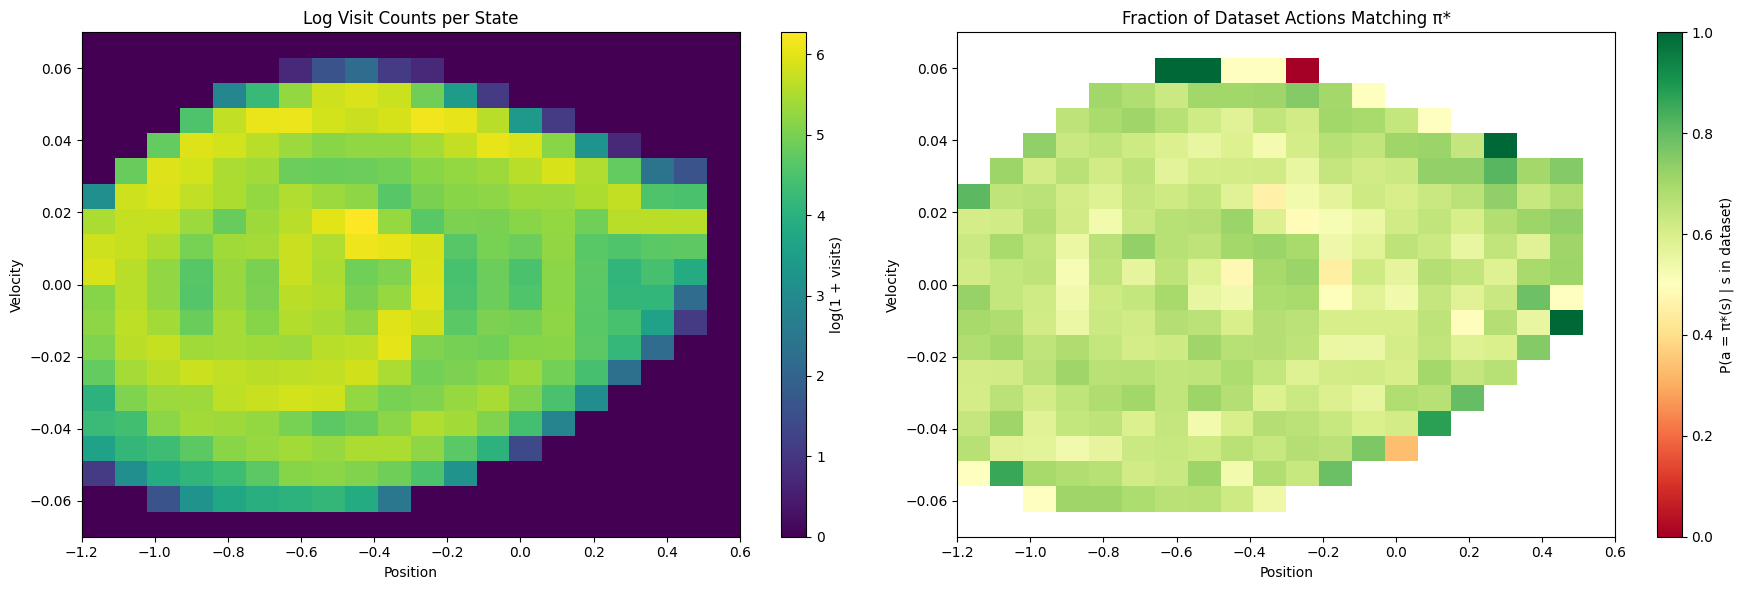

In [30]:
analyzer = DatasetAnalyzer(DATASET_PATH)

analyzer.summary(
    n_states=state_disc.n_states,
    n_actions=action_disc.n_actions,
)

ratio = analyzer.feature_coverage_ratio(
    mdp=mdp,
    policy=pi_matrix_ql,
    beta=1e-3,
    use_optimal_policy=False,
)

print(f"\nCoverage ratio: {ratio:.4f}")

CORE_STATE_COUNT = state_disc.core_state_count
STATE_BINS = state_disc.bins
BIN_EDGES = state_disc.bin_edges

visited_states = set(df["state"].unique())
all_states = set(range(CORE_STATE_COUNT))
unvisited = all_states - visited_states

print(
    f"\nState coverage: {len(visited_states)}/{CORE_STATE_COUNT} "
    f"({100 * len(visited_states) / CORE_STATE_COUNT:.1f}%)"
)
print(f"Unvisited states: {len(unvisited)}")

visit_count_grid = np.zeros(tuple(STATE_BINS), dtype=np.int64)
optimal_match_grid = np.full(tuple(STATE_BINS), fill_value=np.nan)

greedy_actions = torch.argmax(
    torch.as_tensor(pi_matrix_ql, dtype=torch.float64).reshape(
        state_disc.n_states, action_disc.n_actions
    ),
    dim=1,
).cpu().numpy()


for s in all_states:
    i, j = state_disc.state_id_to_multi_bin(s)
    visit_count_grid[i, j] = analyzer.count_state(s)

for s in visited_states:
    if s >= CORE_STATE_COUNT:
        continue

    i, j = state_disc.state_id_to_multi_bin(s)
    total = analyzer.count_state(s)
    on_policy = analyzer.count_pair(s, int(greedy_actions[s]))
    optimal_match_grid[i, j] = on_policy / total if total > 0 else np.nan

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

im0 = axes[0].pcolormesh(
    BIN_EDGES[0],
    BIN_EDGES[1],
    np.log1p(visit_count_grid).T,
    cmap="viridis",
    shading="flat",
)
axes[0].set_title("Log Visit Counts per State")
axes[0].set_xlabel("Position")
axes[0].set_ylabel("Velocity")
fig.colorbar(im0, ax=axes[0], label="log(1 + visits)")

im1 = axes[1].pcolormesh(
    BIN_EDGES[0],
    BIN_EDGES[1],
    optimal_match_grid.T,
    cmap="RdYlGn",
    shading="flat",
    vmin=0,
    vmax=1,
)
axes[1].set_title("Fraction of Dataset Actions Matching π*")
axes[1].set_xlabel("Position")
axes[1].set_ylabel("Velocity")
fig.colorbar(im1, ax=axes[1], label="P(a = π*(s) | s in dataset)")

plt.tight_layout()
plt.show()

In [59]:
solver = FOGASSolverVectorized(
    mdp=mdp,
    csv_path=DATASET_PATH,
    device=device,
    beta=1e-6,
    seed=seed
)

[FOGASSolverVectorized] omega estimated via regression (beta_omega=1.00e-06, n=50000)


In [60]:
# 1. Run the solver with your specific parameters
solver.run(
    alpha=0.0001, 
    eta=0.00002, 
    rho=0.5, 
    tqdm_print=True, 
    T=20000
)

FOGAS:   0%|                                                                                                                     | 0/20000 [00:00<?, ?it/s]

FOGAS: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 20000/20000 [00:28<00:00, 711.29it/s]


tensor([[0.3360, 0.3392, 0.3248],
        [0.3393, 0.3428, 0.3179],
        [0.3453, 0.3454, 0.3093],
        ...,
        [0.3330, 0.3306, 0.3364],
        [0.3333, 0.3326, 0.3341],
        [0.3333, 0.3333, 0.3333]], device='cuda:0', dtype=torch.float64)

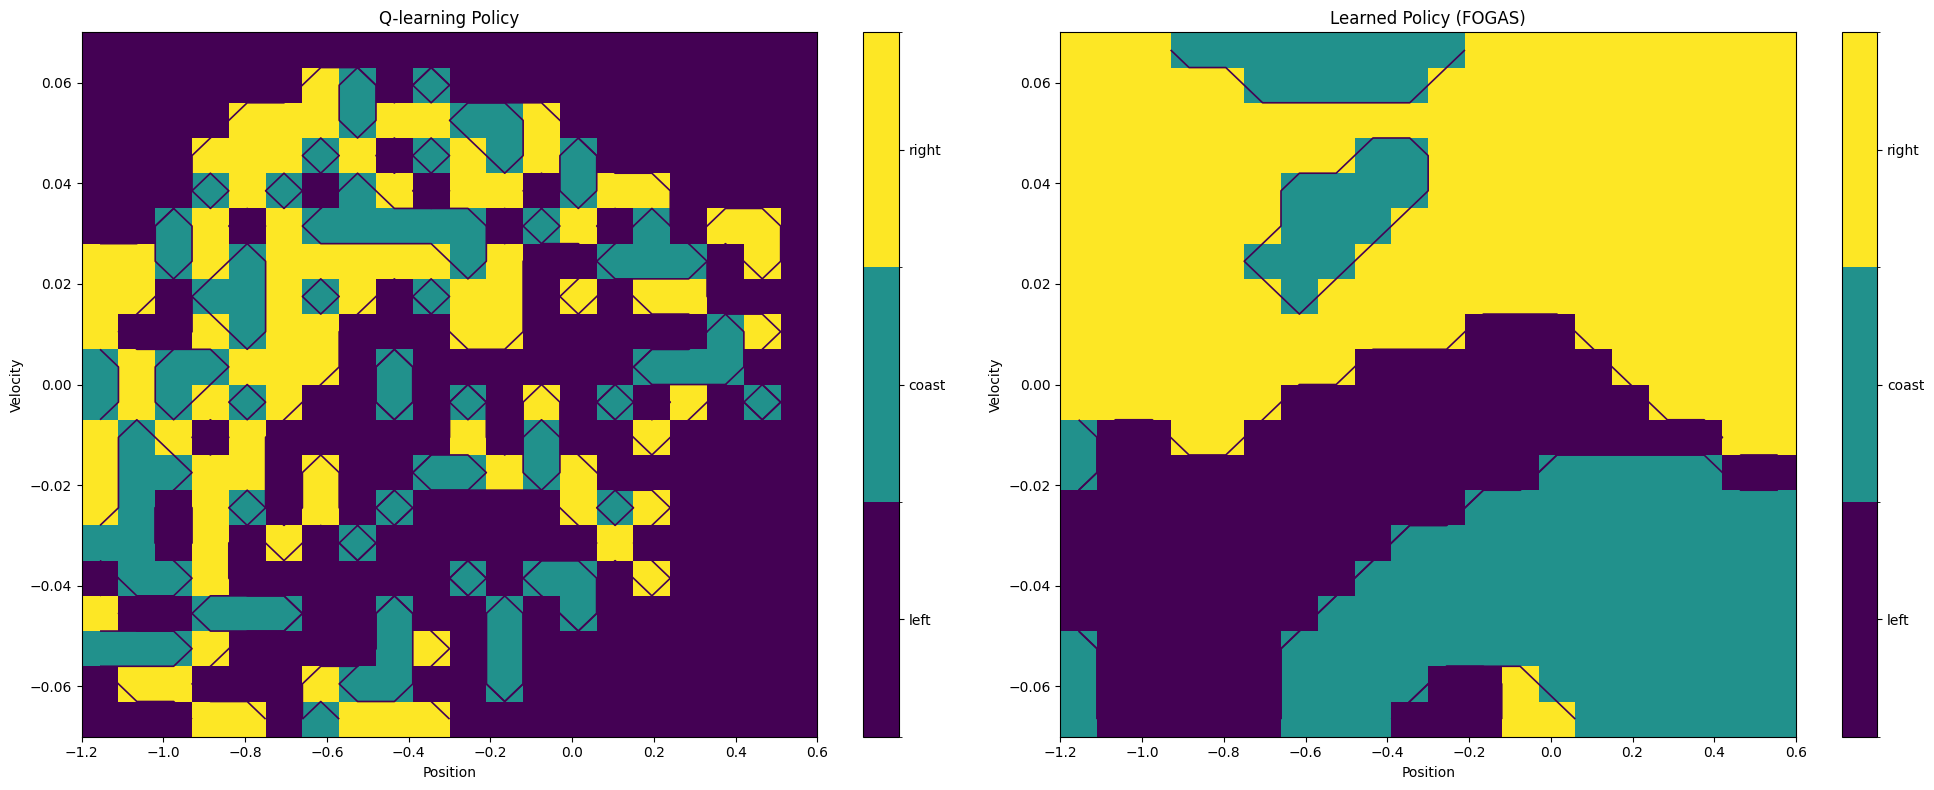

In [61]:
pi_solver = torch.as_tensor(
    solver.pi, dtype=torch.float64
).reshape(state_disc.n_states, action_disc.n_actions).detach().cpu()

pi_ql = torch.as_tensor(
    pi_matrix_ql, dtype=torch.float64
).reshape(state_disc.n_states, action_disc.n_actions).detach().cpu()

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

plot_policy(
    pi_ql,
    state_disc,
    action_disc,
    title="Q-learning Policy",
    ax=axes[0],
)

plot_policy(
    pi_solver,
    state_disc,
    action_disc,
    title="Learned Policy (FOGAS)",
    ax=axes[1],
)

plt.tight_layout()
plt.show()

In [37]:
print_policy_rows(solver.pi, pi_ql, action_disc=action_disc)

AttributeError: 'Tensor' object has no attribute 'n_states'

In [49]:
# Evaluate Random/Heuristic Policy
print("Evaluating Random Policy...")
run_1 = evaluate_policy_mean_steps(torch.zeros((N_STATES, N_ACTIONS)), n_trials=10)

# Evaluate Solver Policy
print("Evaluating Solver Policy...")
run_2 = evaluate_policy_mean_steps(solver.pi, n_trials=10)

print(f"Improvement: {run_1 - run_2} fewer steps!")

Evaluating Random Policy...
Evaluation over 10 trials: Mean Steps = 200.00 (0/10 reached goal)
Evaluating Solver Policy...
Evaluation over 10 trials: Mean Steps = 171.10 (10/10 reached goal)
Improvement: 28.900000000000006 fewer steps!


In [300]:
# 1. Run the solver with your specific parameters
solver.run(
    alpha=0.001, 
    eta=0.00002, 
    rho=0.5, 
    tqdm_print=True, 
    T=20000
)

FOGAS: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20000/20000 [01:39<00:00, 201.66it/s]


tensor([[3.3333e-01, 3.3333e-01, 3.3333e-01],
        [3.9231e-01, 2.5667e-01, 3.5102e-01],
        [3.4311e-01, 3.7771e-01, 2.7919e-01],
        ...,
        [3.3333e-01, 3.3333e-01, 3.3333e-01],
        [3.3333e-01, 3.3333e-01, 3.3333e-01],
        [9.9957e-01, 2.3285e-04, 1.9395e-04]], device='cuda:0',
       dtype=torch.float64)

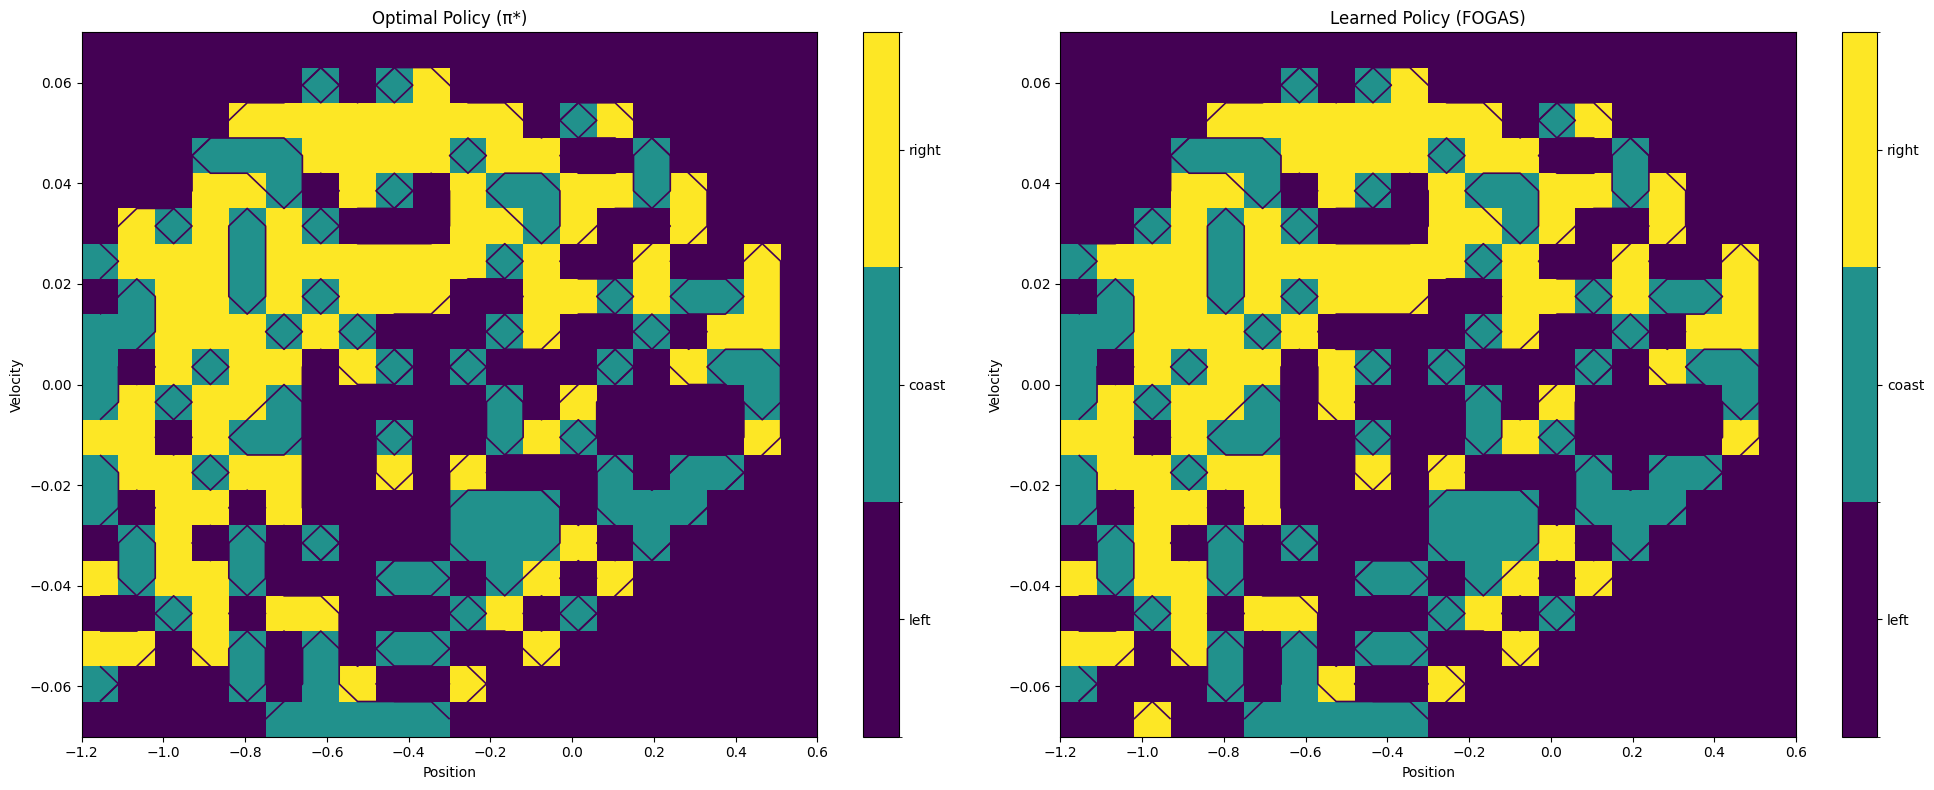

In [301]:
pi_solver = torch.as_tensor(solver.pi, dtype=torch.float64).reshape(N_STATES, N_ACTIONS).detach().cpu()
pi_ql = torch.as_tensor(pi_matrix_ql, dtype=torch.float64).reshape(N_STATES, N_ACTIONS).detach().cpu()

solver_argmax = torch.argmax(pi_solver, dim=1)
solver_argmin = torch.argmin(pi_solver, dim=1)   # leftmost if tie
ql_argmax = torch.argmax(pi_ql, dim=1)

diff_mask = solver_argmax != ql_argmax
diff_mask[GOAL_STATE_ID] = False   # optional

pi_solver_greedy = pi_solver.clone()
pi_solver_greedy[diff_mask] = 0.0
diff_states = torch.where(diff_mask)[0]
pi_solver_greedy[diff_states, solver_argmin[diff_states]] = 1.0

# 1. Create a side-by-side figure
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# 2. Plot the Optimal Policy on the first axis
plot_policy(
    pi_matrix_ql, 
    N_STATES, N_ACTIONS, STATE_BINS, BIN_CENTERS, BIN_EDGES,
    state_id_to_multi_bin,
    CORE_STATE_COUNT=int(np.prod(STATE_BINS)),
    title="Optimal Policy (π*)",
    ax=axes[0]
)

plot_policy(
    pi_solver_greedy, 
    N_STATES, N_ACTIONS, STATE_BINS, BIN_CENTERS, BIN_EDGES,
    state_id_to_multi_bin,
    CORE_STATE_COUNT=int(np.prod(STATE_BINS)),
    title=f"Learned Policy (FOGAS)",
    ax=axes[1]
)

plt.tight_layout()
plt.show()

In [302]:
evaluate_and_save_gif(pi_solver_greedy, "mountain_car_fogas.gif")

Starting simulation for mountain_car_fogas.gif...


ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1334:(snd_func_refer) error evaluating name
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5701:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2664:(snd_pcm_open_noupdate) Unknown PCM default


Success! Reached goal in 186 steps. Total Reward: -186.0
Saving GIF to mountain_car_fogas.gif...
Done!


In [304]:
# Evaluate Random/Heuristic Policy
print("Evaluating Random Policy...")
run_1 = evaluate_policy_mean_steps(torch.zeros((N_STATES, N_ACTIONS)), n_trials=10)

# Evaluate Solver Policy
print("Evaluating Solver Policy...")
run_2 = evaluate_policy_mean_steps(pi_solver_greedy, n_trials=10)

print(f"Improvement: {run_1 - run_2} fewer steps!")

Evaluating Random Policy...
Evaluation over 10 trials: Mean Steps = 200.00 (0/10 reached goal)
Evaluating Solver Policy...
Evaluation over 10 trials: Mean Steps = 179.60 (9/10 reached goal)
Improvement: 20.400000000000006 fewer steps!
